In [3]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19

In [4]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [5]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_reducida = '/home/jhon/bandas/banda13/ene_oct_10m_reducida'

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas
# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 7250 imágenes
Forma de X: (7249, 480, 480, 1)
Forma de y: (7249, 480, 480, 1)


In [6]:
import tensorflow as tf
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Conv2D, Concatenate, Activation, Add
import numpy as np

# Semilla
semilla = 42
tf.random.set_seed(semilla)

print("🔨 CONSTRUYENDO MODELO CON TU CONFIGURACIÓN EXACTA...")

# === CARGAR PESOS VGG19 ===
def cargar_pesos_vgg19():
    vgg_full = tf.keras.applications.VGG19(weights='imagenet', include_top=False)
    pesos = {
        'block1_conv1': vgg_full.get_layer('block1_conv1').get_weights(),
        'block1_conv2': vgg_full.get_layer('block1_conv2').get_weights()
    }
    print("✅ Pesos VGG19 cargados")
    return pesos

vgg_pesos = cargar_pesos_vgg19()

# === CONSTRUCCIÓN PASO A PASO CON TU CONFIGURACIÓN ===
inputs = Input(shape=(480, 480, 1), name='main_input')
print(f"1. Input: {inputs.shape}")

# 2. TU CONFIGURACIÓN EXACTA para expansión de canales
replicate_layer = layers.Conv2D(
    filters=3,              # output channels
    kernel_size=1,          # 1x1 convolution
    use_bias=False,         # no bias needed
    trainable=False,        # freeze the layer
    name="replicate_layer"
)

# IMPORTANTE: Construir la capa ANTES de usarla en el modelo
replicate_layer.build(input_shape=(None, 480, 480, 1))

# Set weights como en tu configuración original
weights = tf.ones((1, 1, 1, 3))  # shape: (kernel_h, kernel_w, in_channels, out_channels)
replicate_layer.set_weights([weights])

# Ahora aplicar la capa al input
x = replicate_layer(inputs)
print(f"2. Replicated: {x.shape}")

# 3. VGG19 Block1 - Conv1
x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(x)
print(f"3. block1_conv1: {x.shape}")

# 4. VGG19 Block1 - Conv2
x = Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
vgg_features = x
print(f"4. block1_conv2: {vgg_features.shape}")

# 5. TU ARQUITECTURA RESIDUAL ORIGINAL COMPLETA
print("5. Construyendo tu arquitectura residual completa...")

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_1')(vgg_features)
x2_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_2')(vgg_features)

res2 = Concatenate(name='concat1')([x2_3, x2_5])

# Proyección para conexión residual
projection = Conv2D(32, (1, 1), padding='same', activation='linear', name='proj1')(vgg_features)
res2 = Add(name='add1')([res2, projection])
res2 = Activation('relu', name='act1')(res2)

print(f"6. Bloque 2: {res2.shape}")

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_3')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_4')(res2)

res3 = Concatenate(name='concat2')([x3_3, x3_5])
res3 = Add(name='add2')([res3, res2])
res3 = Activation('relu', name='act2')(res3)

print(f"7. Bloque 3: {res3.shape}")

# === Bloque 4 ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu', name='conv2d_5')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu', name='conv2d_6')(res3)

res4 = Concatenate(name='concat3')([x4_3, x4_5])
res4 = Add(name='add3')([res4, res3])
res4 = Activation('relu', name='act3')(res4)

print(f"8. Bloque 4: {res4.shape}")

# === Salida ===
outputs = Conv2D(1, (1, 1), padding='same', activation='linear', name='output')(res4)
print(f"9. Output: {outputs.shape}")

# Crear modelo
model_vgg19 = Model(inputs=inputs, outputs=outputs, name='modelo_tu_configuracion')

# === ASIGNAR PESOS PRE-ENTRENADOS ===
print("\n⚡ ASIGNANDO PESOS VGG19...")
model_vgg19.get_layer('block1_conv1').set_weights(vgg_pesos['block1_conv1'])
model_vgg19.get_layer('block1_conv2').set_weights(vgg_pesos['block1_conv2'])
print("✅ Pesos VGG19 asignados")

# === CONGELAR CAPAS ===
model_vgg19.get_layer('replicate_layer').trainable = False
model_vgg19.get_layer('block1_conv1').trainable = False
model_vgg19.get_layer('block1_conv2').trainable = False
print("✅ Capas congeladas: replicate_layer, block1_conv1, block1_conv2")

print("🎉 MODELO CONSTRUIDO CON TU CONFIGURACIÓN EXACTA!")

🔨 CONSTRUYENDO MODELO CON TU CONFIGURACIÓN EXACTA...
✅ Pesos VGG19 cargados
1. Input: (None, 480, 480, 1)
2. Replicated: (None, 480, 480, 3)
3. block1_conv1: (None, 480, 480, 64)
4. block1_conv2: (None, 480, 480, 64)
5. Construyendo tu arquitectura residual completa...
6. Bloque 2: (None, 480, 480, 32)
7. Bloque 3: (None, 480, 480, 32)
8. Bloque 4: (None, 480, 480, 32)
9. Output: (None, 480, 480, 1)

⚡ ASIGNANDO PESOS VGG19...
✅ Pesos VGG19 asignados
✅ Capas congeladas: replicate_layer, block1_conv1, block1_conv2
🎉 MODELO CONSTRUIDO CON TU CONFIGURACIÓN EXACTA!


In [7]:
# === VERIFICACIÓN COMPLETA ===
print("\n=== VERIFICACIÓN COMPLETA ===")

# Verificar la capa replicate_layer
replicate_layer = model_vgg19.get_layer('replicate_layer')
print(f"🔍 replicate_layer config:")
print(f"   - filters: {replicate_layer.filters}")
print(f"   - kernel_size: {replicate_layer.kernel_size}")
print(f"   - use_bias: {replicate_layer.use_bias}")
print(f"   - trainable: {replicate_layer.trainable}")

# Verificar pesos
replicate_weights = replicate_layer.get_weights()
print(f"   - pesos shape: {replicate_weights[0].shape}")
print(f"   - valores: {replicate_weights[0].squeeze()}")

# Test forward pass
test_batch = X[:2]
test_output = model_vgg19.predict(test_batch, verbose=0)
print(f"✅ Forward pass: {test_batch.shape} -> {test_output.shape}")

# Compilar
model_vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae', 'mse']
)
print("✅ Modelo compilado")

# Resumen
print(f"\n📊 RESUMEN:")
total_params = model_vgg19.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_vgg19.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"🔹 Parámetros totales: {total_params:,}")
print(f"🔹 Parámetros entrenables: {trainable_params:,}")
print(f"🔹 Parámetros no entrenables: {non_trainable_params:,}")
print(f"🔹 Porcentaje entrenable: {(trainable_params/total_params)*100:.1f}%")


=== VERIFICACIÓN COMPLETA ===
🔍 replicate_layer config:
   - filters: 3
   - kernel_size: (1, 1)
   - use_bias: False
   - trainable: False
   - pesos shape: (1, 1, 1, 3)
   - valores: [1. 1. 1.]


I0000 00:00:1763298909.284876   37312 service.cc:146] XLA service 0x7cd2b0003c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763298909.284901   37312 service.cc:154]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2025-11-16 08:15:09.297064: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-16 08:15:09.359193: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


✅ Forward pass: (2, 480, 480, 1) -> (2, 480, 480, 1)
✅ Modelo compilado

📊 RESUMEN:
🔹 Parámetros totales: 110,564
🔹 Parámetros entrenables: 71,841
🔹 Parámetros no entrenables: 38,723
🔹 Porcentaje entrenable: 65.0%


I0000 00:00:1763298910.310648   37312 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [ ]:
# === ENTRENAMIENTO CON MAPE BUILT-IN ===
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# Callbacks optimizados
callbacks = [
    ModelCheckpoint(
        'vgg19_1.h5',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=12,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger('historial_mape.csv')
]

# Configuración
BATCH_SIZE = 8
EPOCHS = 50

# COMPILACIÓN SIMPLE CON MAPE BUILT-IN
model_vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("✅ Modelo compilado con MAPE built-in")
print("🔹 Loss: mean_absolute_percentage_error")
print("🔹 MAPE se mostrará como porcentaje")

print(f"\n🚀 INICIANDO ENTRENAMIENTO CON MAPE...")

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

history_vgg19 = model_vgg19.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
    shuffle=True
)

print("🎉 ¡ENTRENAMIENTO CON MAPE COMPLETADO!")

✅ Modelo compilado con MAPE built-in
🔹 Loss: mean_absolute_percentage_error
🔹 MAPE se mostrará como porcentaje

🚀 INICIANDO ENTRENAMIENTO CON MAPE...
Epoch 1/50
907/907 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 4.0867 - mean_absolute_percentage_error: 239.7100 - root_mean_squared_error: 1.6458
Epoch 1: val_loss improved from None to 0.03762, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 150s 148ms/step - loss: 0.8135 - mean_absolute_percentage_error: 99.1494 - root_mean_squared_error: 0.9020 - val_loss: 0.0376 - val_mean_absolute_percentage_error: 40.8562 - val_root_mean_squared_error: 0.1939 - learning_rate: 5.0000e-05
Epoch 2/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0326 - mean_absolute_percentage_error: 37.7569 - root_mean_squared_error: 0.1803
Epoch 2: val_loss improved from 0.03762 to 0.02378, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 121s 134ms/step - loss: 0.0285 - mean_absolute_percentage_error: 35.6152 - root_mean_squared_error: 0.1688 - val_loss: 0.0238 - val_mean_absolute_percentage_error: 34.9254 - val_root_mean_squared_error: 0.1542 - learning_rate: 5.0000e-05
Epoch 3/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0208 - mean_absolute_percentage_error: 30.6976 - root_mean_squared_error: 0.1443
Epoch 3: val_loss improved from 0.02378 to 0.01759, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 124s 137ms/step - loss: 0.0193 - mean_absolute_percentage_error: 29.8153 - root_mean_squared_error: 0.1391 - val_loss: 0.0176 - val_mean_absolute_percentage_error: 29.7992 - val_root_mean_squared_error: 0.1326 - learning_rate: 5.0000e-05
Epoch 4/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0165 - mean_absolute_percentage_error: 27.5383 - root_mean_squared_error: 0.1286
Epoch 4: val_loss improved from 0.01759 to 0.01447, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 124s 137ms/step - loss: 0.0158 - mean_absolute_percentage_error: 27.2156 - root_mean_squared_error: 0.1258 - val_loss: 0.0145 - val_mean_absolute_percentage_error: 26.3672 - val_root_mean_squared_error: 0.1203 - learning_rate: 5.0000e-05
Epoch 5/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0142 - mean_absolute_percentage_error: 25.8033 - root_mean_squared_error: 0.1192
Epoch 5: val_loss did not improve from 0.01447
907/907 ━━━━━━━━━━━━━━━━━━━━ 123s 136ms/step - loss: 0.0137 - mean_absolute_percentage_error: 25.6244 - root_mean_squared_error: 0.1171 - val_loss: 0.0150 - val_mean_absolute_percentage_error: 29.9124 - val_root_mean_squared_error: 0.1226 - learning_rate: 5.0000e-05
Epoch 6/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0128 - mean_absolute_percentage_error: 24.8831 - root_mean_squared_error: 0.1131
Epoch 6: val_loss improved from 0.01447 to 0.01151, saving model to vgg19_1.h5


...

907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0065 - mean_absolute_percentage_error: 18.4543 - root_mean_squared_error: 0.0805 - val_loss: 0.0063 - val_mean_absolute_percentage_error: 18.5950 - val_root_mean_squared_error: 0.0793 - learning_rate: 5.0000e-05
Epoch 35/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0066 - mean_absolute_percentage_error: 18.6275 - root_mean_squared_error: 0.0812
Epoch 35: val_loss did not improve from 0.00629
907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0065 - mean_absolute_percentage_error: 18.4276 - root_mean_squared_error: 0.0804 - val_loss: 0.0063 - val_mean_absolute_percentage_error: 18.6706 - val_root_mean_squared_error: 0.0793 - learning_rate: 5.0000e-05
Epoch 36/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0066 - mean_absolute_percentage_error: 18.6284 - root_mean_squared_error: 0.0812
Epoch 36: val_loss did not improve from 0.00629
907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0064 - mean_absolute_perc

907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0064 - mean_absolute_percentage_error: 18.3190 - root_mean_squared_error: 0.0800 - val_loss: 0.0062 - val_mean_absolute_percentage_error: 18.4292 - val_root_mean_squared_error: 0.0789 - learning_rate: 5.0000e-05
Epoch 38/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0065 - mean_absolute_percentage_error: 18.5110 - root_mean_squared_error: 0.0808
Epoch 38: val_loss did not improve from 0.00622
907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0064 - mean_absolute_percentage_error: 18.3092 - root_mean_squared_error: 0.0800 - val_loss: 0.0063 - val_mean_absolute_percentage_error: 18.7127 - val_root_mean_squared_error: 0.0793 - learning_rate: 5.0000e-05
Epoch 39/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0065 - mean_absolute_percentage_error: 18.4474 - root_mean_squared_error: 0.0806
Epoch 39: val_loss did not improve from 0.00622
907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0064 - mean_absolute_perc

907/907 ━━━━━━━━━━━━━━━━━━━━ 123s 135ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.6528 - root_mean_squared_error: 0.0779 - val_loss: 0.0062 - val_mean_absolute_percentage_error: 18.4704 - val_root_mean_squared_error: 0.0784 - learning_rate: 2.5000e-05
Epoch 48/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.7261 - root_mean_squared_error: 0.0783
Epoch 48: val_loss did not improve from 0.00615
907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.7295 - root_mean_squared_error: 0.0781 - val_loss: 0.0071 - val_mean_absolute_percentage_error: 21.5008 - val_root_mean_squared_error: 0.0843 - learning_rate: 2.5000e-05
Epoch 49/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0062 - mean_absolute_percentage_error: 17.8351 - root_mean_squared_error: 0.0786
Epoch 49: val_loss improved from 0.00615 to 0.00613, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.7584 - root_mean_squared_error: 0.0781 - val_loss: 0.0061 - val_mean_absolute_percentage_error: 18.3761 - val_root_mean_squared_error: 0.0783 - learning_rate: 2.5000e-05
Epoch 50/50
906/907 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.7583 - root_mean_squared_error: 0.0783
Epoch 50: val_loss improved from 0.00613 to 0.00608, saving model to vgg19_1.h5


907/907 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - loss: 0.0061 - mean_absolute_percentage_error: 17.7431 - root_mean_squared_error: 0.0781 - val_loss: 0.0061 - val_mean_absolute_percentage_error: 18.1901 - val_root_mean_squared_error: 0.0780 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 50.
🎉 ¡ENTRENAMIENTO CON MAPE COMPLETADO!


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0061, RMSE final: 0.0781, MAPE final: 17.7431
Validación    - Loss final: 0.0061, RMSE final: 0.0780, MAPE final: 18.1901


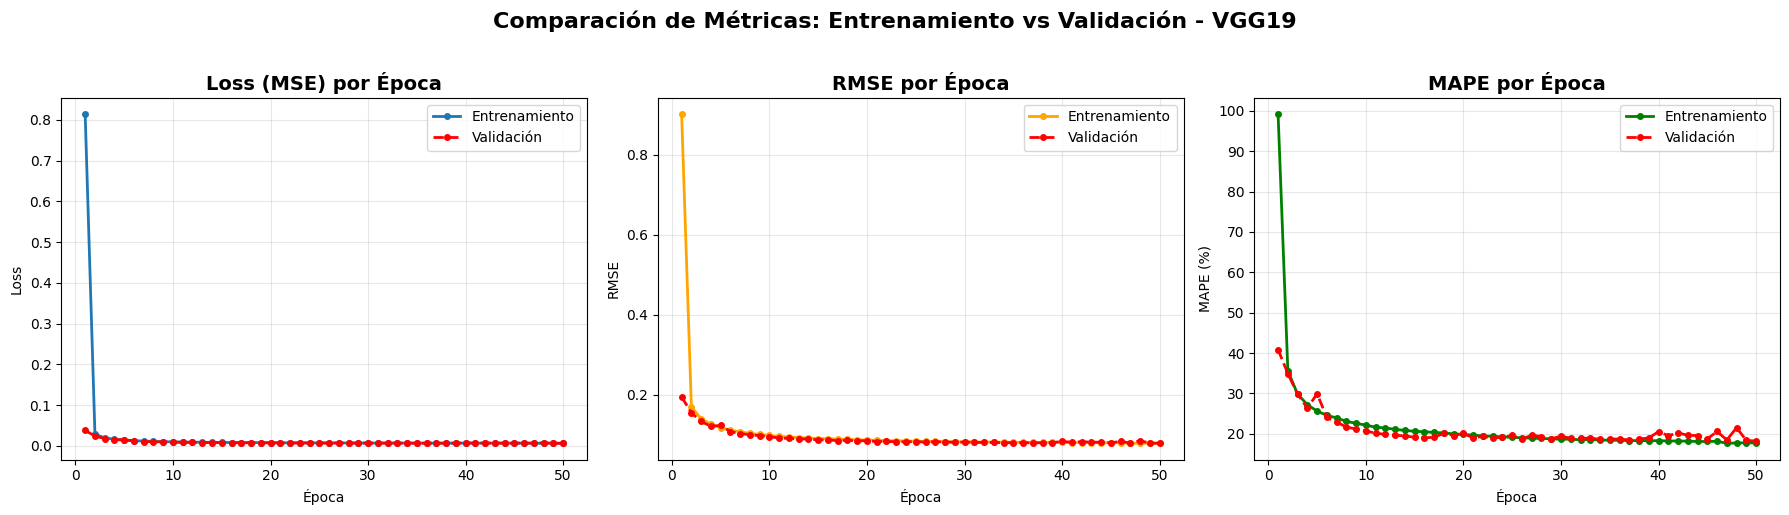

In [11]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history_vgg19.history['loss']
val_loss = history_vgg19.history['val_loss']

rmse = history_vgg19.history['root_mean_squared_error']
val_rmse = history_vgg19.history['val_root_mean_squared_error']
mape = history_vgg19.history['mean_absolute_percentage_error']
val_mape = history_vgg19.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - VGG19',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model_vgg19.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

227/227 ━━━━━━━━━━━━━━━━━━━━ 49s 159ms/step - loss: 0.0061 - mean_absolute_percentage_error: 18.3690 - root_mean_squared_error: 0.0783
Pérdida (MSE): 0.0061
RMSE: 0.0783
MAPE: 18.3690


In [ ]:
# Obtener las métricas del modelo en el conjunto de validation
loss, rmse, mape = model_vgg19.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

📊 MÉTRICAS DEL ENTRENAMIENTO:
Mejor pérdida de validación: 0.0061
Mejor MAPE de validación: 18.19%
Última pérdida de validación: 0.0061
Último MAPE de validación: 18.19%


Visualización de imagenes

227/227 ━━━━━━━━━━━━━━━━━━━━ 27s 120ms/step


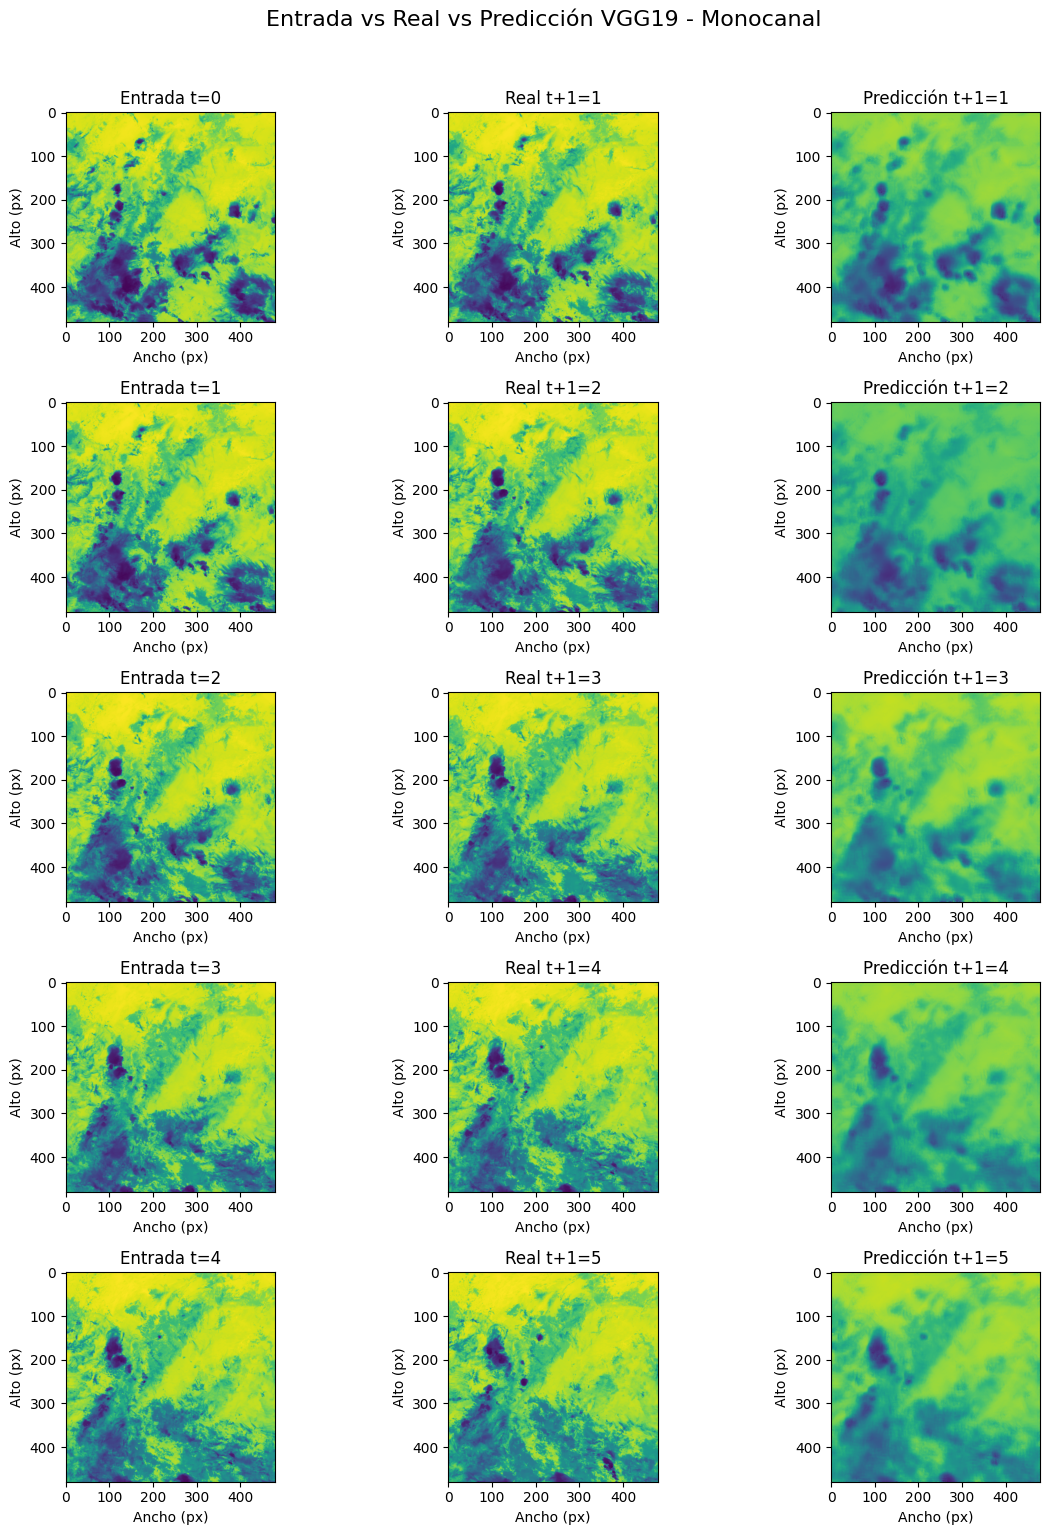

In [ ]:
y_vgg12 = model_vgg19.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_vgg12, n=5,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

prueba

In [21]:
# Directorio original y reducido para validación
d_mar_2s_red = '/home/jhon/bandas/banda13/nov_dic_2m_red'

# Llamar a la función para redimensionar imágenes

# Cargar imágenes de validación
file_list_test = sorted([f for f in os.listdir(d_mar_2s_red) if f.endswith('.npy')])
print(f"Procesando {len(file_list_test)} imágenes para validación")

images_test = [np.load(os.path.join(d_mar_2s_red, f)) for f in file_list_test]

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida


Procesando 1447 imágenes para validación
Forma de X: (1446, 480, 480, 1)
Forma de y: (1446, 480, 480, 1)


Metricas de testeo

In [22]:
# Obtener las métricas del modelo en el conjunto de test
loss, rmse, mape = model_vgg19.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - loss: 0.0070 - mean_absolute_percentage_error: 20.6022 - root_mean_squared_error: 0.0836
Pérdida (MSE): 0.0070
RMSE: 0.0836
MAPE: 20.6022


46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step


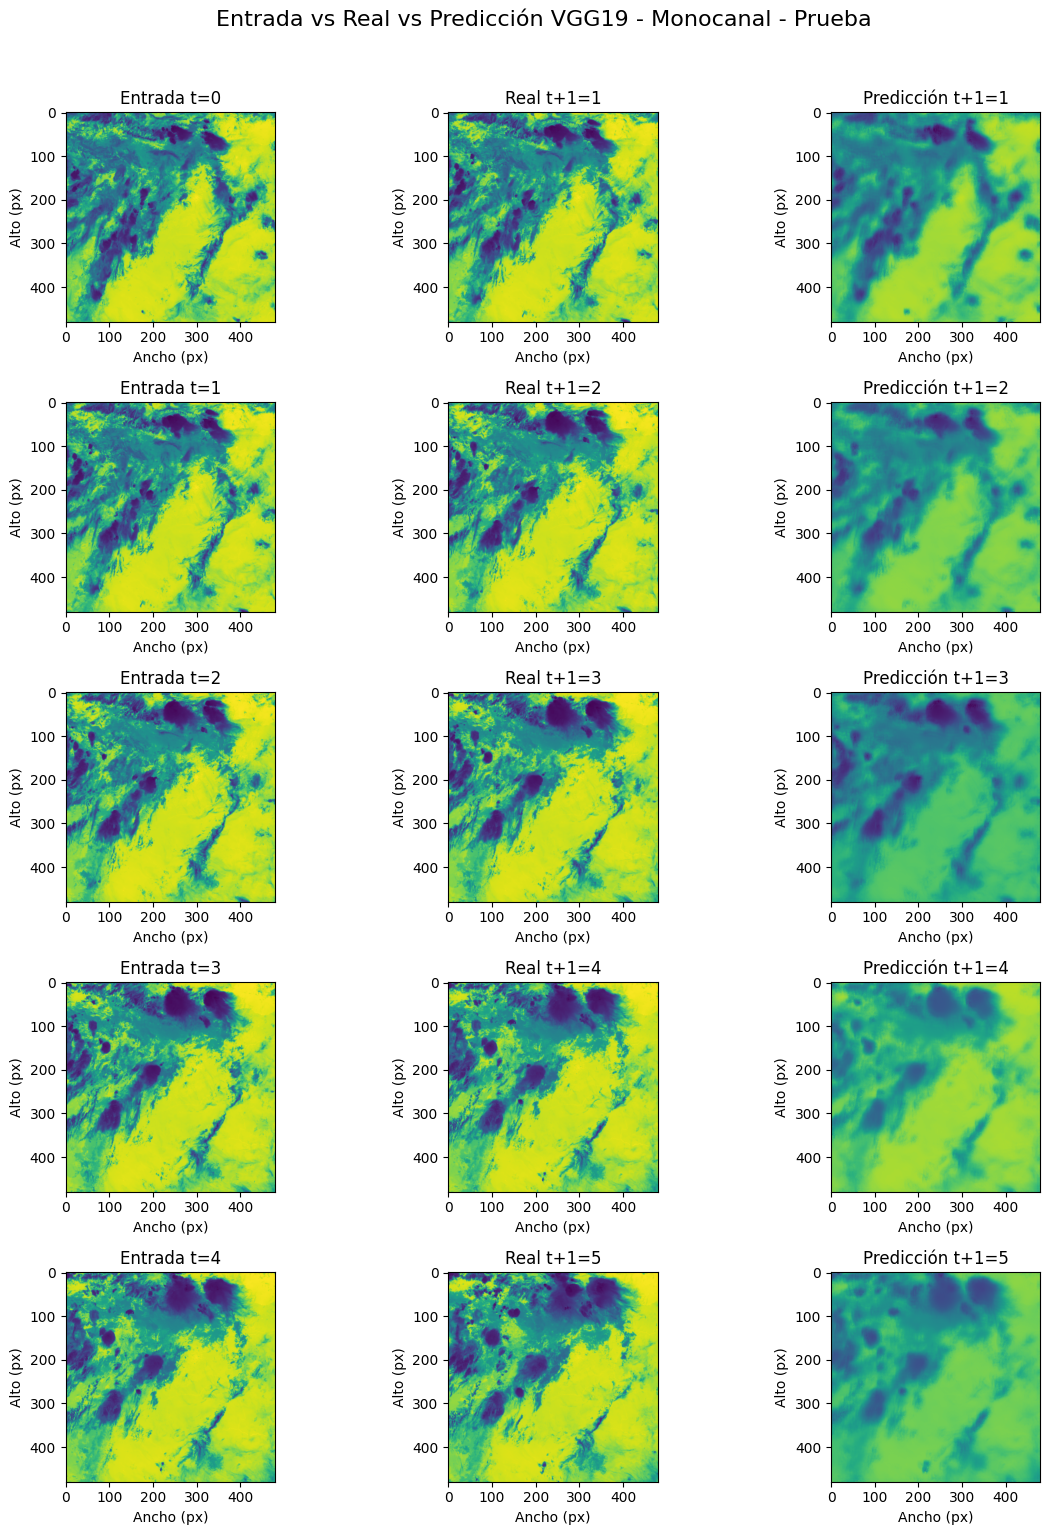

In [23]:
y_vgg19_test = model_vgg19.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_vgg19_test, n=5,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
    )

In [ ]:
mostrar_resultados(
    X_test, y_test, y_vgg19_test, n=2,
    titulo_general="Entrada vs Real vs Predicción VGG19 - Monocanal - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
    )